# Capítulo 11 · Sobreajuste en redes neuronales

En el capítulo anterior aprendimos a leer las curvas de entrenamiento y validación. Ahora construiremos deliberadamente una situación de sobreajuste para observar qué ocurre cuando una red aprende detalles específicos del conjunto de entrenamiento en lugar de limitarse al patrón general.

Después aplicaremos una combinación de menor capacidad, regularización L2, dropout y *early stopping*. El objetivo no será obtener la menor pérdida de entrenamiento, sino favorecer la generalización.

## Objetivos del capítulo

Al finalizar este recorrido podrás:

- reconocer el sobreajuste en curvas y métricas;
- relacionarlo con la capacidad del modelo, la cantidad de datos, el ruido y el tiempo de entrenamiento;
- comparar una red pequeña con otra sobredimensionada;
- interpretar la diferencia entre memorizar particularidades y aprender patrones generales;
- aplicar regularización L2 y dropout con Keras;
- comprobar que dropout se comporta de manera diferente durante entrenamiento y predicción;
- combinar regularización con *early stopping*;
- comparar modelos sin considerar la *accuracy* de entrenamiento como objetivo final;
- proponer experimentos donde se modifique una sola decisión por vez.

## Importación de librerías

Continuaremos con `make_moons`, pero usaremos menos observaciones y más ruido. El ejemplo sigue siendo pequeño y puede ejecutarse con CPU.

In [1]:
import os

# Reduce mensajes técnicos que no forman parte de la práctica.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["TF_NUM_INTEROP_THREADS"] = "1"
os.environ["TF_NUM_INTRAOP_THREADS"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers, regularizers

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.4f}".format

SEMILLA_DATOS = 42
SEMILLA_MODELO = 42
LEARNING_RATE = 0.005

print(f"TensorFlow: {tf.__version__}")
print("GPU disponible:", bool(tf.config.list_physical_devices("GPU")))

TensorFlow: 2.20.0
GPU disponible: False


## 1. Menos datos y más ruido

Reduciremos el dataset de 1000 a 300 observaciones y aumentaremos `noise` de 0.15 a 0.25. Reservaremos validación y prueba de manera explícita para mantener los tres roles utilizados en el capítulo anterior.

In [2]:
X, y = make_moons(
    n_samples=300,
    noise=0.25,
    random_state=SEMILLA_DATOS,
)

X = X.astype("float32")
y = y.astype("float32")

X_desarrollo, X_test, y_desarrollo, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEMILLA_DATOS,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_desarrollo,
    y_desarrollo,
    test_size=0.20,
    random_state=SEMILLA_DATOS,
    stratify=y_desarrollo,
)

particiones = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Validación", "Prueba"],
    "Observaciones": [len(X_train), len(X_val), len(X_test)],
    "Clase 0": [
        int((y_train == 0).sum()),
        int((y_val == 0).sum()),
        int((y_test == 0).sum()),
    ],
    "Clase 1": [
        int((y_train == 1).sum()),
        int((y_val == 1).sum()),
        int((y_test == 1).sum()),
    ],
})

display(particiones)

,Conjunto,Observaciones,Clase 0,Clase 1
0,Entrenamiento,192,96,96
1,Validación,48,24,24
2,Prueba,60,30,30


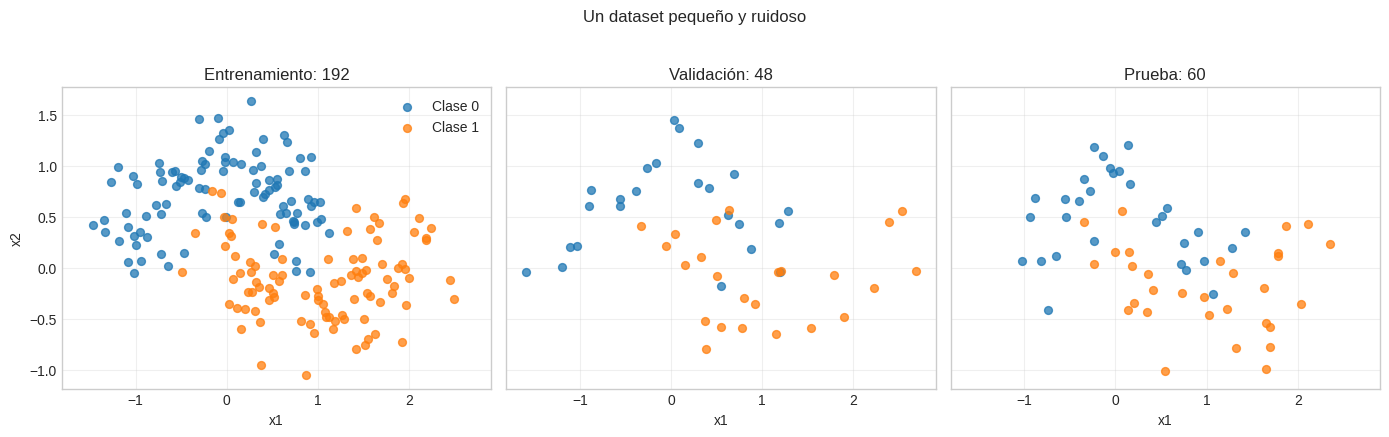

In [3]:
conjuntos = [
    (X_train, y_train, "Entrenamiento"),
    (X_val, y_val, "Validación"),
    (X_test, y_test, "Prueba"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharex=True, sharey=True)

for ax, (X_parte, y_parte, nombre) in zip(axes, conjuntos):
    ax.scatter(
        X_parte[y_parte == 0, 0],
        X_parte[y_parte == 0, 1],
        s=32,
        alpha=0.75,
        label="Clase 0",
    )
    ax.scatter(
        X_parte[y_parte == 1, 0],
        X_parte[y_parte == 1, 1],
        s=32,
        alpha=0.75,
        label="Clase 1",
    )
    ax.set_title(f"{nombre}: {len(X_parte)}")
    ax.set_xlabel("x1")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("x2")
axes[0].legend()
fig.suptitle("Un dataset pequeño y ruidoso", y=1.03)
plt.tight_layout()
plt.show()

La red contará con solo 192 observaciones para aprender. Los puntos aislados y la superposición entre clases ofrecen oportunidades para que un modelo con mucha capacidad se adapte a excepciones particulares.

Una observación difícil no es necesariamente un patrón que deba reproducirse en datos nuevos.

## 2. Una red deliberadamente grande

Nuestra primera red utilizaba la arquitectura $2\rightarrow8\rightarrow4\rightarrow1$ y tenía 65 parámetros. Para provocar sobreajuste construiremos:

$$
2\rightarrow128\rightarrow128\rightarrow64\rightarrow64\rightarrow1
$$

No afirmamos que toda red grande sobreajuste. En este experimento combinamos mucha capacidad, pocos datos, ruido y un entrenamiento prolongado para que el fenómeno resulte visible.

In [4]:
def crear_modelo_grande():
    keras.backend.clear_session()
    keras.utils.set_random_seed(SEMILLA_MODELO)

    modelo = keras.Sequential([
        keras.Input(shape=(2,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])

    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

    return modelo


modelo_grande = crear_modelo_grande()
modelo_grande.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,377 (114.75 KB)

 Trainable params: 29,377 (114.75 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
comparacion_capacidad = pd.DataFrame({
    "Modelo": ["Red de los capítulos 9 y 10", "Red deliberadamente grande"],
    "Arquitectura": ["2 → 8 → 4 → 1", "2 → 128 → 128 → 64 → 64 → 1"],
    "Parámetros": [65, modelo_grande.count_params()],
    "Observaciones de entrenamiento": [len(X_train), len(X_train)],
})
comparacion_capacidad["Parámetros por observación"] = (
    comparacion_capacidad["Parámetros"]
    / comparacion_capacidad["Observaciones de entrenamiento"]
)

display(comparacion_capacidad)

,Modelo,Arquitectura,Parámetros,Observaciones de entrenamiento,Parámetros por observación
0,Red de los capítulos 9 y 10,2 → 8 → 4 → 1,65,192,0.3385
1,Red deliberadamente grande,2 → 128 → 128 → 64 → 64 → 1,29377,192,153.0052


La red grande contiene 29.377 parámetros: alrededor de 452 veces más que la arquitectura original y muchos más parámetros que observaciones de entrenamiento.

Esta relación aumenta el riesgo de memorizar, pero no constituye por sí sola una prueba. La evidencia aparecerá al observar qué ocurre con entrenamiento y validación.

## 3. Darle tiempo para sobreajustar

Entrenaremos las 300 epochs completas sin `EarlyStopping`. El valor es deliberado: queremos dejar que la red continúe adaptándose incluso después de que validación deje de mejorar.

El mismo *learning rate*, batch size y particiones se reutilizarán en la versión regularizada para que la comparación conserve condiciones comunes.

In [6]:
historial_grande = modelo_grande.fit(
    X_train,
    y_train,
    epochs=300,
    batch_size=16,
    validation_data=(X_val, y_val),
    shuffle=True,
    verbose=0,
)

tabla_grande = pd.DataFrame(historial_grande.history)
tabla_grande.index = np.arange(1, len(tabla_grande) + 1)
tabla_grande.index.name = "Epoch"

mejor_epoch_grande = int(tabla_grande["val_loss"].idxmin())
print("Mejor epoch según val_loss:", mejor_epoch_grande)
print("Menor val_loss:", f"{tabla_grande['val_loss'].min():.4f}")

Mejor epoch según val_loss: 77
Menor val_loss: 0.2909


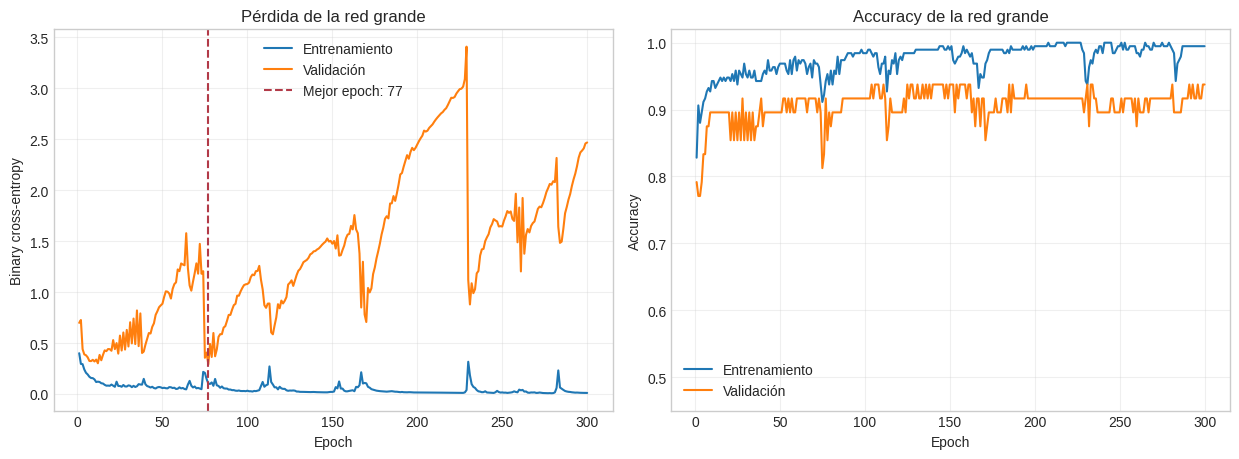

In [7]:
eje_grande = tabla_grande.index.to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.7))

axes[0].plot(eje_grande, tabla_grande["loss"], label="Entrenamiento")
axes[0].plot(eje_grande, tabla_grande["val_loss"], label="Validación")
axes[0].axvline(
    mejor_epoch_grande,
    color="#b23a48",
    linestyle="--",
    label=f"Mejor epoch: {mejor_epoch_grande}",
)
axes[0].set_title("Pérdida de la red grande")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary cross-entropy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(eje_grande, tabla_grande["accuracy"], label="Entrenamiento")
axes[1].plot(eje_grande, tabla_grande["val_accuracy"], label="Validación")
axes[1].set_title("Accuracy de la red grande")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.45, 1.02)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Al principio ambas pérdidas disminuyen. Después, la pérdida de entrenamiento continúa acercándose a cero mientras la de validación cambia de dirección y aumenta. La *accuracy* de entrenamiento se aproxima a 1, pero validación no acompaña esa mejora.

La separación sostenida de las curvas muestra el sobreajuste con más claridad que el tamaño de la red por sí solo.

In [8]:
ultima_epoch = int(tabla_grande.index[-1])

resumen_sobreajuste = pd.DataFrame({
    "Momento": ["Mejor validación", "Final del entrenamiento"],
    "Epoch": [mejor_epoch_grande, ultima_epoch],
    "Loss entrenamiento": [
        tabla_grande.loc[mejor_epoch_grande, "loss"],
        tabla_grande.loc[ultima_epoch, "loss"],
    ],
    "Loss validación": [
        tabla_grande.loc[mejor_epoch_grande, "val_loss"],
        tabla_grande.loc[ultima_epoch, "val_loss"],
    ],
    "Accuracy entrenamiento": [
        tabla_grande.loc[mejor_epoch_grande, "accuracy"],
        tabla_grande.loc[ultima_epoch, "accuracy"],
    ],
    "Accuracy validación": [
        tabla_grande.loc[mejor_epoch_grande, "val_accuracy"],
        tabla_grande.loc[ultima_epoch, "val_accuracy"],
    ],
})

display(resumen_sobreajuste)

,Momento,Epoch,Loss entrenamiento,Loss validación,Accuracy entrenamiento,Accuracy validación
0,Mejor validación,77,0.1032,0.2909,0.9427,0.9167
1,Final del entrenamiento,300,0.0102,2.4688,0.9948,0.9375


Entre la mejor epoch y la última, el modelo mejora su ajuste al entrenamiento pero empeora según la pérdida de validación. Continuar entrenando no produjo una solución más general.

La *accuracy* puede ocultar parte del deterioro porque solo registra si cada probabilidad quedó a un lado u otro del umbral. Binary Cross-Entropy también penaliza las predicciones equivocadas realizadas con mucha confianza.

## 4. Estrategias disponibles

| Estrategia | Qué intenta controlar |
|---|---|
| *Early stopping* | Evita continuar después de que validación deja de mejorar. |
| Red más pequeña | Reduce la capacidad disponible para memorizar detalles. |
| Regularización L2 | Agrega un costo asociado con pesos grandes. |
| Dropout | Desactiva aleatoriamente activaciones durante el entrenamiento. |
| Más datos representativos | Obliga a encontrar patrones útiles en una variedad mayor de casos. |
| *Data augmentation* | Crea variaciones válidas cuando el tipo de dato lo permite. |

No conviene aplicar estas opciones como una receta automática. La estrategia debe responder al diagnóstico y una regularización excesiva puede producir subajuste.

## 5. Una versión orientada a generalizar

Construiremos la versión propuesta en el capítulo:

$$
2\rightarrow32\rightarrow16\rightarrow1
$$

Las capas densas utilizarán L2 con $\lambda=0.001$ y después de cada una agregaremos dropout de 0.2. También recuperaremos `EarlyStopping`, ya presentado en el capítulo anterior.

Esta versión cambia varias decisiones a la vez para mostrar cómo se combinan las técnicas. Más adelante plantearemos cómo aislar sus efectos mediante experimentos controlados.

In [9]:
def crear_modelo_regularizado():
    keras.backend.clear_session()
    keras.utils.set_random_seed(SEMILLA_MODELO)

    modelo = keras.Sequential([
        keras.Input(shape=(2,)),
        layers.Dense(
            32,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001),
        ),
        layers.Dropout(0.2),
        layers.Dense(
            16,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001),
        ),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ])

    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

    return modelo


modelo_regularizado = crear_modelo_regularizado()
modelo_regularizado.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

La versión regularizada tiene 641 parámetros. Las capas dropout no agregan pesos: modifican temporalmente las activaciones durante el entrenamiento.

L2 sí modifica la cantidad que optimizamos al sumar una penalización asociada con los pesos de las dos capas ocultas.

In [10]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
)

historial_regularizado = modelo_regularizado.fit(
    X_train,
    y_train,
    epochs=300,
    batch_size=16,
    validation_data=(X_val, y_val),
    shuffle=True,
    callbacks=[early_stopping],
    verbose=0,
)

tabla_regularizada = pd.DataFrame(historial_regularizado.history)
tabla_regularizada.index = np.arange(1, len(tabla_regularizada) + 1)
tabla_regularizada.index.name = "Epoch"

mejor_epoch_regularizada = int(tabla_regularizada["val_loss"].idxmin())

print("Máximo permitido: 300")
print("Epochs ejecutadas:", len(tabla_regularizada))
print("Mejor epoch según val_loss:", mejor_epoch_regularizada)
print("Menor val_loss:", f"{tabla_regularizada['val_loss'].min():.4f}")

Máximo permitido: 300
Epochs ejecutadas: 77
Mejor epoch según val_loss: 57
Menor val_loss: 0.3130


El entrenamiento regularizado se detiene antes del máximo y recupera los pesos correspondientes al menor `val_loss`. La paciencia de 20 tolera fluctuaciones en un conjunto de validación pequeño; no constituye un valor universal.

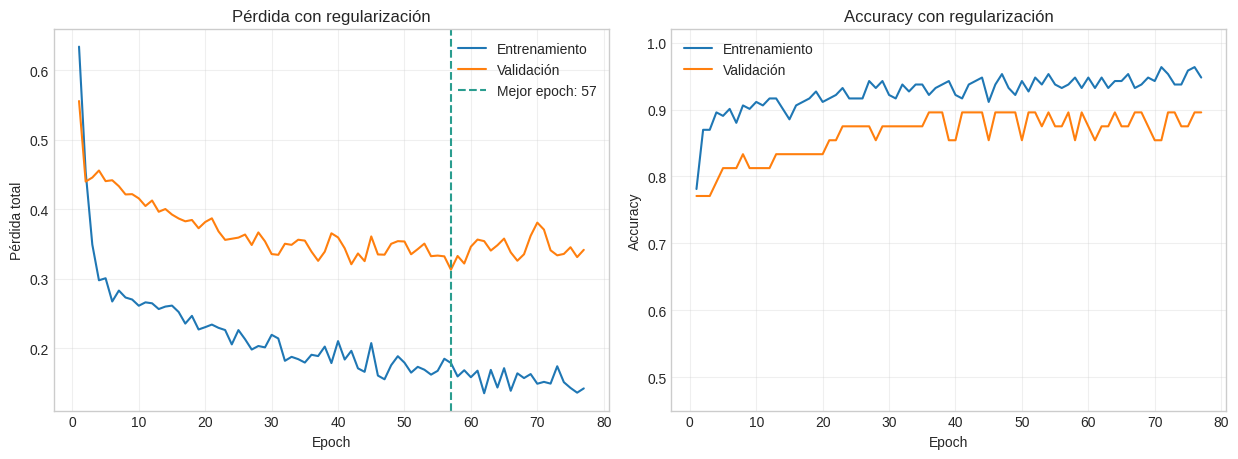

In [11]:
eje_regularizado = tabla_regularizada.index.to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.7))

axes[0].plot(
    eje_regularizado,
    tabla_regularizada["loss"],
    label="Entrenamiento",
)
axes[0].plot(
    eje_regularizado,
    tabla_regularizada["val_loss"],
    label="Validación",
)
axes[0].axvline(
    mejor_epoch_regularizada,
    color="#2a9d8f",
    linestyle="--",
    label=f"Mejor epoch: {mejor_epoch_regularizada}",
)
axes[0].set_title("Pérdida con regularización")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Pérdida total")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    eje_regularizado,
    tabla_regularizada["accuracy"],
    label="Entrenamiento",
)
axes[1].plot(
    eje_regularizado,
    tabla_regularizada["val_accuracy"],
    label="Validación",
)
axes[1].set_title("Accuracy con regularización")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.45, 1.02)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Las curvas ya no muestran una pérdida de entrenamiento cercana a cero. Eso no constituye un fracaso: L2 y dropout dificultan la adaptación perfecta a los ejemplos conocidos, mientras `EarlyStopping` evita prolongar el entrenamiento sin mejoras de validación.

En esta gráfica, `loss` incluye la penalización L2, por lo que no debe interpretarse como si fuera únicamente Binary Cross-Entropy.

## 6. Comparar sobre los tres conjuntos

Recién ahora evaluaremos ambos modelos sobre prueba. El modelo grande conserva los pesos de su epoch 300; el regularizado restauró los correspondientes a su mejor `val_loss`.

La pérdida informada por Keras no tiene exactamente la misma composición: en el modelo regularizado incluye Binary Cross-Entropy más la penalización L2. Como esa penalización es positiva, no favorece artificialmente a la versión regularizada; de todos modos, interpretaremos la comparación junto con la *accuracy* y las curvas.

In [12]:
def evaluar_en_particiones(modelo, nombre):
    filas = []

    for conjunto, X_parte, y_parte in [
        ("Entrenamiento", X_train, y_train),
        ("Validación", X_val, y_val),
        ("Prueba", X_test, y_test),
    ]:
        perdida, accuracy = modelo.evaluate(X_parte, y_parte, verbose=0)
        filas.append({
            "Modelo": nombre,
            "Conjunto": conjunto,
            "Loss de Keras": perdida,
            "Accuracy": accuracy,
        })

    return filas


comparacion_final = pd.DataFrame(
    evaluar_en_particiones(modelo_grande, "Grande, epoch 300")
    + evaluar_en_particiones(modelo_regularizado, "Regularizado")
)

display(comparacion_final)

,Modelo,Conjunto,Loss de Keras,Accuracy
0,"Grande, epoch 300",Entrenamiento,0.0092,0.9948
1,"Grande, epoch 300",Validación,2.4688,0.9375
2,"Grande, epoch 300",Prueba,3.4848,0.8833
3,Regularizado,Entrenamiento,0.1397,0.9583
4,Regularizado,Validación,0.3130,0.8958
5,Regularizado,Prueba,0.3094,0.8833


La red grande logra una *accuracy* de entrenamiento casi perfecta, pero su pérdida aumenta con fuerza fuera de ese conjunto. El modelo regularizado acepta un ajuste menos extremo y obtiene una pérdida mucho menor sobre prueba, incluso aunque su cifra incorpora la penalización L2.

En esta ejecución ambas *accuracies* de prueba pueden resultar parecidas. La diferencia de pérdida recuerda que dos modelos capaces de acertar la misma cantidad de clases pueden asignar probabilidades muy distintas. Un único experimento no establece una técnica universalmente superior.

## 7. Comparar las fronteras de decisión

Como seguimos trabajando con dos variables, podemos observar la función aprendida por cada red. Mostraremos la frontera del modelo grande después de 300 epochs y la del modelo regularizado con sus mejores pesos restaurados.

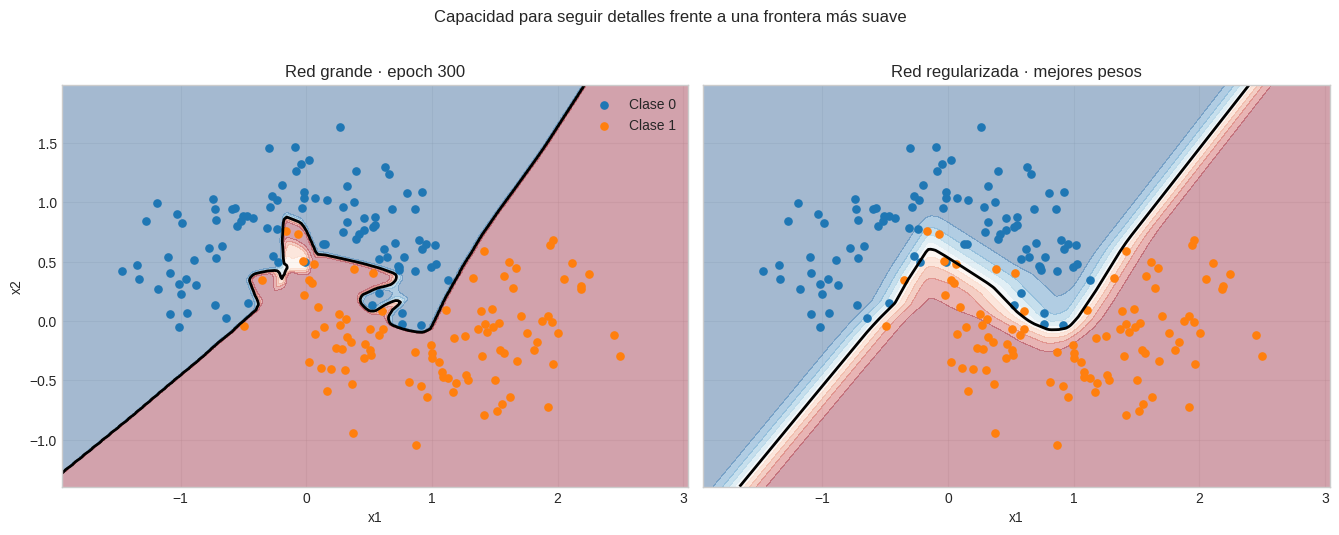

In [13]:
margen = 0.35
x1_min, x1_max = X[:, 0].min() - margen, X[:, 0].max() + margen
x2_min, x2_max = X[:, 1].min() - margen, X[:, 1].max() + margen

xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 260),
    np.linspace(x2_min, x2_max, 260),
)
grilla = np.column_stack([xx1.ravel(), xx2.ravel()]).astype("float32")

prob_grande = modelo_grande.predict(grilla, verbose=0).reshape(xx1.shape)
prob_regularizada = modelo_regularizado.predict(grilla, verbose=0).reshape(xx1.shape)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), sharex=True, sharey=True)

for ax, probabilidades, titulo in [
    (axes[0], prob_grande, "Red grande · epoch 300"),
    (axes[1], prob_regularizada, "Red regularizada · mejores pesos"),
]:
    ax.contourf(
        xx1,
        xx2,
        probabilidades,
        levels=np.linspace(0, 1, 11),
        cmap="RdBu_r",
        alpha=0.38,
    )
    ax.contour(
        xx1,
        xx2,
        probabilidades,
        levels=[0.5],
        colors="black",
        linewidths=2,
    )
    ax.scatter(
        X_train[y_train == 0, 0],
        X_train[y_train == 0, 1],
        s=27,
        label="Clase 0",
    )
    ax.scatter(
        X_train[y_train == 1, 0],
        X_train[y_train == 1, 1],
        s=27,
        label="Clase 1",
    )
    ax.set_title(titulo)
    ax.set_xlabel("x1")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("x2")
axes[0].legend()
fig.suptitle("Capacidad para seguir detalles frente a una frontera más suave", y=1.02)
plt.tight_layout()
plt.show()

La frontera del modelo grande presenta desvíos destinados a seguir puntos concretos del entrenamiento. La versión regularizada produce una separación más suave y menos dependiente de irregularidades individuales.

Una frontera suave no es automáticamente correcta, pero en este ejemplo coincide con una pérdida de prueba sensiblemente menor.

## 8. Qué hacen L2 y dropout en el código

La pérdida total del modelo regularizado puede pensarse como:

$$
L_{total}=L_{datos}+L_{L2}
$$

Dropout actúa de otra manera: genera distintas combinaciones de activaciones durante el entrenamiento, pero se desactiva en la predicción normal. Comprobaremos ambos comportamientos sobre una pequeña muestra.

In [14]:
muestra_X = X_train[:16]
muestra_y = y_train[:16].reshape(-1, 1)

probabilidades_muestra = modelo_regularizado(muestra_X, training=False)
perdida_datos = tf.reduce_mean(
    keras.losses.binary_crossentropy(muestra_y, probabilidades_muestra)
).numpy()
penalizacion_l2 = tf.add_n(modelo_regularizado.losses).numpy()

componentes_perdida = pd.DataFrame({
    "Componente": ["Binary cross-entropy de la muestra", "Penalización L2"],
    "Valor": [perdida_datos, penalizacion_l2],
})
display(componentes_perdida)

muestra_dropout = X_val[:4]
salida_entrenamiento_1 = modelo_regularizado(
    muestra_dropout,
    training=True,
).numpy().ravel()
salida_entrenamiento_2 = modelo_regularizado(
    muestra_dropout,
    training=True,
).numpy().ravel()
salida_prediccion_1 = modelo_regularizado.predict(
    muestra_dropout,
    verbose=0,
).ravel()
salida_prediccion_2 = modelo_regularizado.predict(
    muestra_dropout,
    verbose=0,
).ravel()

comparacion_dropout = pd.DataFrame({
    "Entrenamiento 1": salida_entrenamiento_1,
    "Entrenamiento 2": salida_entrenamiento_2,
    "Predicción 1": salida_prediccion_1,
    "Predicción 2": salida_prediccion_2,
})
display(comparacion_dropout)

,Componente,Valor
0,Binary cross-entropy de la muestra,0.0354
1,Penalización L2,0.0312


,Entrenamiento 1,Entrenamiento 2,Predicción 1,Predicción 2
0,0.7808,0.1790,0.2956,0.2956
1,1.0000,1.0000,1.0000,1.0000
2,0.1494,0.0504,0.0635,0.0635
3,0.9990,0.9974,0.9931,0.9931


L2 agrega un término positivo a la pérdida y hace costosas las soluciones basadas en pesos grandes. Las dos columnas de entrenamiento pueden diferir porque dropout desactiva activaciones aleatoriamente en cada pasada.

Las columnas de predicción coinciden: durante `predict()` dropout no elimina neuronas y Keras utiliza automáticamente el modo de inferencia.

## 9. Más datos y data augmentation

Una red tiene menos oportunidades de memorizar ejemplos individuales cuando dispone de más datos **representativos y variados**. Duplicar exactamente las mismas filas no aporta información nueva.

En algunos dominios pueden crearse variaciones válidas. Esa técnica se denomina *data augmentation*. No la implementaremos aquí: cobra especial sentido con imágenes y será retomada cuando el libro llegue a ese tipo de datos. Las transformaciones siempre deben conservar el significado y la etiqueta del ejemplo.

## 10. Actividad: cambiar una sola decisión

La versión regularizada combina una red menor, L2, dropout y *early stopping*. Por eso no podemos atribuir todo el cambio a una única técnica.

Para realizar un experimento controlado, creá una copia de `crear_modelo_regularizado()` y modificá solo uno de estos elementos:

- quitá las dos capas `Dropout`, conservando L2;
- conservá dropout, pero quitá `kernel_regularizer`;
- usá la red grande con `EarlyStopping`;
- conservá toda la arquitectura y cambiá únicamente `Dropout(0.2)` por `Dropout(0.4)`.

Entrená con las mismas particiones, el mismo máximo de epochs, el mismo batch size y el mismo optimizador. Después compará las curvas y las métricas de validación. Una *accuracy* de entrenamiento menor no implica por sí sola un peor modelo.

## 11. Señales y respuestas posibles

| Señal observada | Respuesta que conviene investigar |
|---|---|
| `loss` baja mientras `val_loss` sube | Detener antes o limitar la capacidad. |
| Gran brecha entre entrenamiento y validación | Probar una red menor, L2 o dropout. |
| Frontera muy irregular | Revisar si el modelo está siguiendo ruido o excepciones. |
| Red grande y muy pocos datos | Conseguir más variedad o reducir el modelo. |
| Ambas curvas permanecen malas y cercanas | Evitar regularizar aún más; podría existir subajuste. |

El diagnóstico resulta más sólido cuando varias señales apuntan en la misma dirección. No existe una receta universal contra el sobreajuste.

## Cierre

En este capítulo provocamos sobreajuste mediante un dataset pequeño y ruidoso, una red de 29.377 parámetros y un entrenamiento prolongado. Las curvas mostraron que reducir la pérdida de entrenamiento después de cierto punto empeoraba el comportamiento sobre validación.

Después construimos una red de 641 parámetros con L2, dropout y *early stopping*. Comprobamos que regularizar puede impedir un ajuste perfecto al entrenamiento y, al mismo tiempo, producir probabilidades más razonables sobre datos no utilizados para aprender.

El objetivo no es hacer la red lo más pequeña posible ni agregar todas las técnicas disponibles. Buscamos un equilibrio entre capacidad para aprender y capacidad para generalizar, mediante diagnósticos y comparaciones controladas.

Con este capítulo cerramos el primer bloque de redes densas. El próximo capítulo comenzará a estudiar cómo se representan las imágenes, sin introducir todavía arquitecturas convolucionales.

## Para pensar

1. ¿Por qué una *accuracy* de entrenamiento cercana a 1 puede ser una señal de alarma en lugar de una garantía de calidad?
2. ¿Qué evidencia de las curvas permite distinguir una red grande de una red que efectivamente sobreajusta?
3. ¿Por qué dropout produce salidas diferentes con `training=True`, pero no durante `predict()`?
4. ¿Qué riesgo aparece si aplicamos L2, dropout, una red menor y otro optimizador al mismo tiempo?
5. ¿Por qué repetir exactamente las mismas observaciones no equivale a conseguir más datos útiles?

---

### Autoría y atribución

Este cuaderno forma parte del material educativo desarrollado por **VintaBytes**.

📧 **Contacto:** [vintabytes@gmail.com](mailto:vintabytes@gmail.com)

🌐 **Repositorio oficial:** [github.com/VintaBytes/Ciencia-de-datos](https://github.com/VintaBytes/Ciencia-de-datos)

Se permite compartir y reutilizar este material respetando la autoría y manteniendo visible esta atribución.

---
